# TODO 리스트를 활용한 플래닝 에이전트 만들기

복잡한 장기 작업 수행 시, 에이전트는 **TODO List**를 핵심 내비게이션 도구로 활용합니다.   
이는 **Context Rot** 및 목표에서 벗어나는 것을 방지하고 작업 방향을 일관성 있게 유지하는 데 필수적입니다.

*   **구조**: `content`(작업 설명)와 `status`(pending, in_progress, completed)로 구성
*   **효과**: 툴 호출 증가에 따른 컨텍스트 손실 방지 및 작업 집중력 유지

> **Tip**: TODO 리스트의 지속적인 갱신(Update)은 에이전트의 장기 기억력을 보완해줍니다.

**참고 자료**
*   [Claude Code Plan Mode](https://www.anthropic.com/engineering/claude-code-best-practices)
*   [Context Rot 에 대한 개념](https://research.trychroma.com/context-rot)
*   [Manus 컨텍스트 엔지니어링](https://manus.im/blog/Context-Engineering-for-AI-Agents-Lessons-from-Building-Manus)

In [2]:
from dotenv import load_dotenv

load_dotenv()

True

---

## State 설계

워크플로우 컨텍스트 저장을 위한 `DeepAgentState` 구조를 정의합니다.  
`AgentState`를 상속받아, todo 라는 추가 요소를 포함합니다.

*   **`todos`**: 작업 리스트 (`Todo` 객체 리스트)

In [4]:
from state import DeepAgentState

# DeepAgentState를 TODO 전용으로 alias 처리만 함
TodoDeepAgentState = DeepAgentState

---

## 도구 설계

### TODO 관리 툴

에이전트가 목표를 관리하기 위한 `write_todos` 및 `read_todos` 툴의 역할은 다음과 같습니다.

*   **`write_todos`**: 전체 TODO 리스트를 재작성하여 State 갱신 (작업 추가/수정/상태 변경)
*   **`read_todos`**: 현재 State의 TODO 리스트 조회
*   **운영 방식**: 개별 항목 수정이 아닌 리스트 전체 갱신을 통해 유연한 목표 관리 지원

복잡한 워크플로우 진행 상황 추적을 위한 구조화된 작업 목록 생성 및 관리

**사용 시점**

- 조율이 필요한 다단계 또는 복잡한 작업
- 사용자가 여러 작업을 제공하거나 명시적으로 TODO 목록을 요청한 경우
- 단순 작업에는 사용 지양 (별도 지시가 없는 한)

**구조**

- 여러 TODO 객체(content, status, id)를 포함하는 단일 목록 유지
- 명확하고 실행 가능한 내용 설명 사용
- status 값: pending, in_progress, completed

**모범 사례**

- 동시에 in_progress 상태는 하나의 작업만 허용
- 작업 완료 즉시 completed로 표시
- 변경 시 항상 전체 업데이트된 목록 전송
- 목록 집중도 유지를 위해 불필요한 항목 정리

**진행 상황 업데이트**

- 작업 상태 변경 또는 내용 수정 시 TodoWrite 재호출
- 실시간 진행 상황 반영, 완료 건 일괄 처리 금지
- 차단 발생 시 in_progress 유지 및 차단 사유 설명하는 새 작업 추가

**파라미터**

- todos: content 및 status 필드를 포함한 TODO 항목 목록

**반환값**

- 새 TODO 목록으로 에이전트 상태 업데이트

---

### `write_todos` 및 `read_todos` 툴 구현

`ToolRuntime`과 `Command`를 활용하여 실제 툴을 구현합니다.

*   **`write_todos`**: 입력받은 TODO 리스트로 State를 업데이트하고, 변경 내역을 `ToolMessage`로 기록
*   **`read_todos`**: State에서 현재 TODO 리스트를 읽어 포맷팅된 문자열을 `ToolMessage`로 반환 (Command 사용)

In [6]:
from tools import read_todos, web_search, write_todos

## Graph 구축

`create_agent`를 사용하여 TODO 리스트를 적극적으로 활용하는 에이전트를 구축합니다.

- **설계 목표**: 작업 완료 시마다 TODO 리스트를 재확인(Recitation)하는 전략 적용
- **기대 효과**: 장기 작업 시 목표 이탈 방지 및 일관성 유지

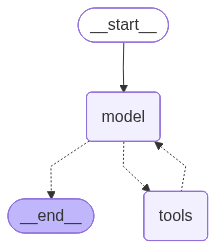

In [7]:
from langchain.agents import create_agent
from langchain.chat_models import init_chat_model
from prompts import SIMPLE_RESEARCH_INSTRUCTIONS, TODO_USAGE_INSTRUCTIONS

# 모델 초기화
model = init_chat_model(model="openai:gpt-4.1", temperature=0.0)

# 에이전트에 사용할 툴 리스트 정의
tools = [write_todos, read_todos, web_search]

# 에이전트 생성
agent = create_agent(
    model,
    tools,
    system_prompt=TODO_USAGE_INSTRUCTIONS
    + "\n\n"
    + "=" * 80
    + "\n\n"
    + SIMPLE_RESEARCH_INSTRUCTIONS,
    state_schema=TodoDeepAgentState,
)
agent

In [ ]:
agent.ainvoke({"messages": []})